# 4. CME comparison and density calibration

Benchmark the Polymarket Student-t (and Gaussian) implied rates against **CME 30-day Fed Funds futures**:

- Invert futures quotes to an implied average rate, then map to the target **upper bound** using the EFFR–upper-bound basis.
- RMSE versus realized FOMC outcomes at several horizons (0–3 days through 31–60 days).
- Probability Integral Transform (PIT) tests of density calibration (KS and Cramér–von Mises).

Reads `fed_rates_fred.csv` and the fitted Gaussian / Student-t CSVs. Downloads `ZQ=F` from Yahoo Finance if you re-run the futures pull.

In [ ]:
import requests
import pandas as pd
import time
import json
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm
from scipy.optimize import minimize
import yfinance as yf
import datetime
from scipy import stats


In [33]:
fed_funds_futures = yf.download("ZQ=F", start="2023-01-01", end="2026-05-01")


C:\Users\steph\AppData\Local\Temp\ipykernel_36792\1821589881.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  fed_funds_futures = yf.download("ZQ=F", start="2023-01-01", end="2026-05-01")
[*********************100%***********************]  1 of 1 completed


In [34]:
fed_funds_futures['Implied_Rate_futures'] = 100 - fed_funds_futures['Close']

In [35]:
fed = pd.read_csv('fed_rates_fred.csv', parse_dates=['Date'])

In [36]:
fed.rename(columns={'Actual_Fed_Rate': 'Actual_Fed_Rate_upper'}, inplace=True)

In [37]:
fed['Date'] = pd.to_datetime(fed['Date'])

In [38]:
import pandas_datareader.data as web
start = datetime.datetime(2023, 1, 1) # Adjust start year as needed
end = datetime.datetime.today()
fed_actual = web.DataReader('DFF', 'fred', start, end)
fed_actual.reset_index(inplace=True)
fed_actual.rename(columns={'DFF': 'Actual_Fed_Rate', 'DATE': 'Date'}, inplace=True)

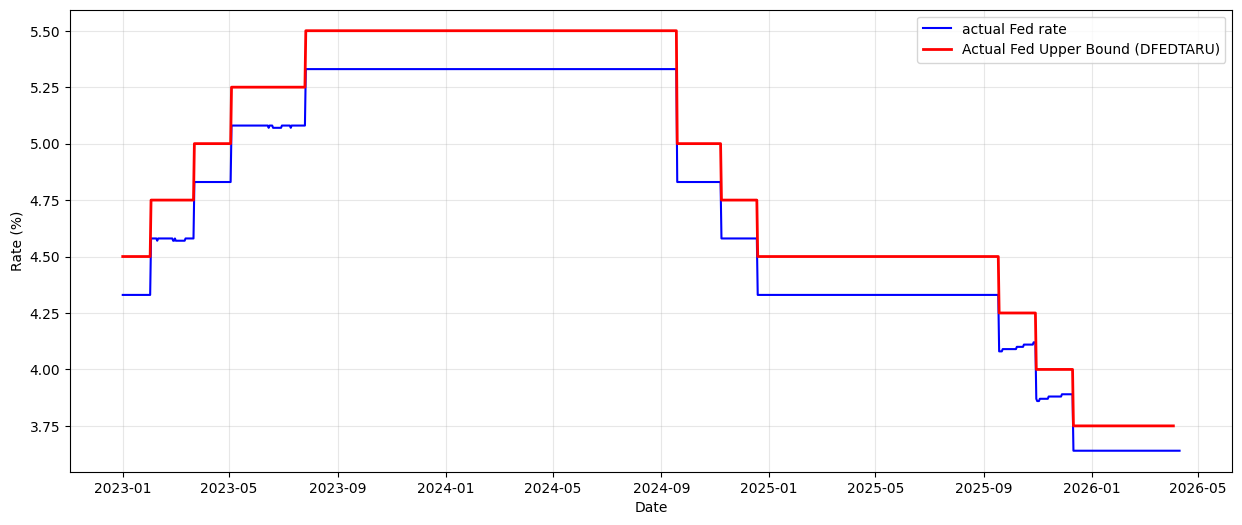

In [ ]:


plt.figure(figsize=(15, 6))

sns.lineplot(data=fed_actual, x='Date', 
             y='Actual_Fed_Rate', label='actual Fed rate', color='blue')

sns.lineplot(data=fed, x='Date', y='Actual_Fed_Rate_upper', 
             label='Actual Fed Upper Bound (DFEDTARU)', color='red', linewidth=2)

plt.ylabel("Rate (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<Axes: >

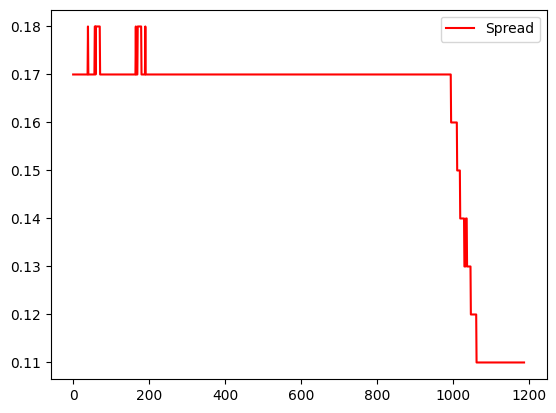

In [45]:
sns.lineplot( fed['Actual_Fed_Rate_upper']-fed_actual['Actual_Fed_Rate'], label='Spread', color='red')

In [ ]:
latest_upper_bound = fed['Actual_Fed_Rate_upper'].iloc[400]
latest_effective_rate = fed_actual['Actual_Fed_Rate'].iloc[400]

current_spread = latest_upper_bound - latest_effective_rate

print(f"Current Spread to apply: {current_spread:.4f}%")

Current Spread to apply: 0.1700%


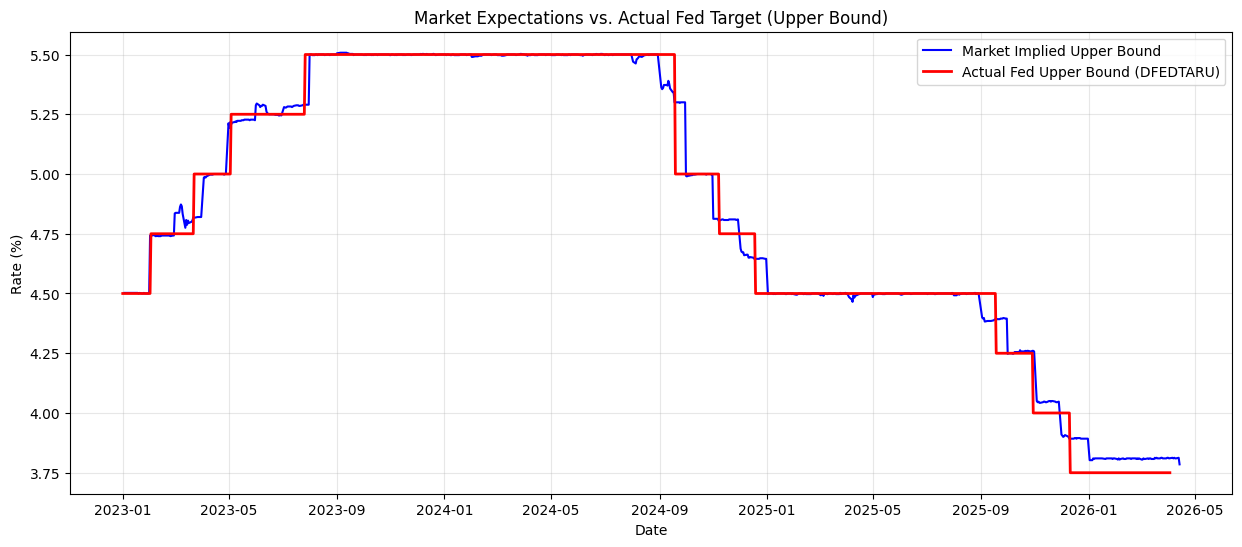

In [ ]:
fed_funds_futures['Implied_Upper_Bound'] = fed_funds_futures['Implied_Rate_futures'] + current_spread

plt.figure(figsize=(15, 6))

sns.lineplot(data=fed_funds_futures, x=fed_funds_futures.index, 
             y='Implied_Upper_Bound', label='Market Implied Upper Bound', color='blue')

sns.lineplot(data=fed, x='Date', y='Actual_Fed_Rate_upper', 
             label='Actual Fed Upper Bound (DFEDTARU)', color='red', linewidth=2)

plt.title("Market Expectations vs. Actual Fed Target (Upper Bound)")
plt.ylabel("Rate (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [65]:
gaussian = pd.read_csv('daily_fed_rate_distribution_gaussian_estimation.csv')
student_t = pd.read_csv('daily_fed_rate_distribution_student_t_estimation.csv')
gaussian['Date'] = pd.to_datetime(gaussian['Date'])
student_t['Date'] = pd.to_datetime(student_t['Date'])

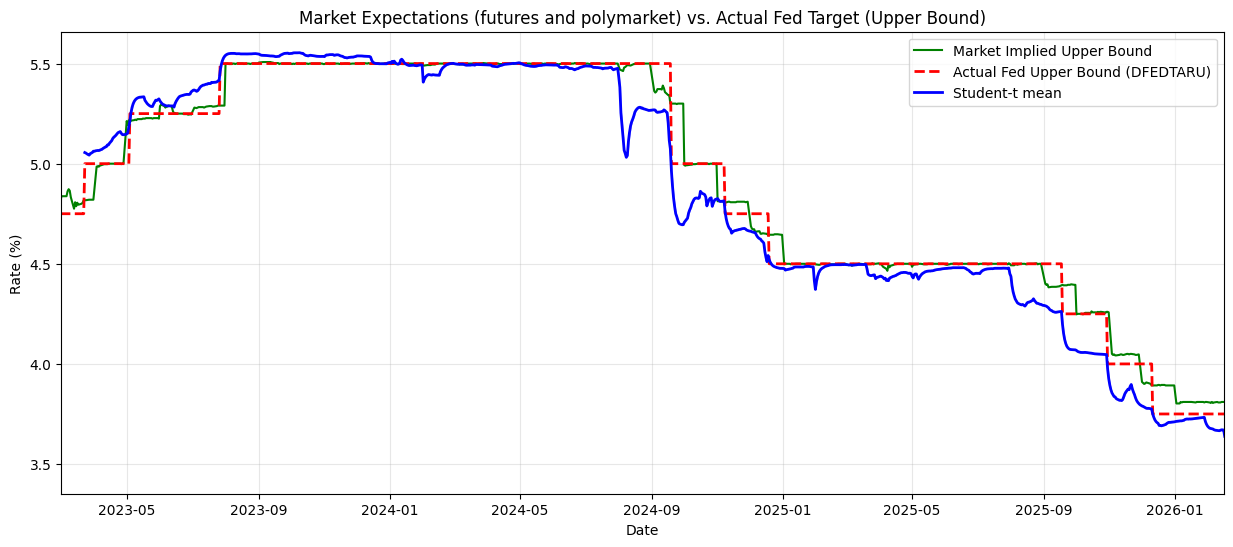

In [75]:
plt.figure(figsize=(15, 6))

sns.lineplot(data=fed_funds_futures, x=fed_funds_futures.index, 
             y='Implied_Upper_Bound', label='Market Implied Upper Bound', color='green')

sns.lineplot(data=fed, x='Date', y='Actual_Fed_Rate_upper', 
             label='Actual Fed Upper Bound (DFEDTARU)', color='red', linewidth=2,linestyle='--')


sns.lineplot(data=student_t, x='Date', y='smoothed_mu', 
             label='Student-t mean', color='blue', linewidth=2)

plt.title("Market Expectations (futures and polymarket) vs. Actual Fed Target (Upper Bound)")
plt.ylabel("Rate (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(pd.to_datetime("2023-03-01"), pd.to_datetime("2026-02-15"))
plt.show()

In [185]:
gaussian = pd.read_csv('daily_fed_rate_distribution_gaussian_estimation.csv')
student_t = pd.read_csv('daily_fed_rate_distribution_student_t_estimation.csv')
gaussian['Date'] = pd.to_datetime(gaussian['Date'])
student_t['Date'] = pd.to_datetime(student_t['Date'])

In [186]:
meeting_dates = gaussian.groupby('Event_Slug')['Date'].max().reset_index()
meeting_dates.rename(columns={'Date': 'Meeting_Date'}, inplace=True)
gaussian=pd.merge(gaussian,meeting_dates,on='Event_Slug',how='left')
merged_data = pd.merge(gaussian[['Date','smoothed_mu','smoothed_sigma','Meeting_Date']], student_t[['Date','smoothed_mu','smoothed_sigma','smoothed_nu']], on='Date', suffixes=('_gaussian', '_student_t')).drop_duplicates()
merged_data = pd.merge(merged_data, fed, on='Date', 
                                              ).ffill()
merged_data = pd.merge(merged_data, fed_funds_futures['Implied_Upper_Bound'], on='Date', 
                                              ).ffill().drop_duplicates()


In [187]:
is_meeting = (merged_data['Date'] == merged_data['Meeting_Date'])
next_row_mask = is_meeting.shift(1, fill_value=False)

result  = merged_data[next_row_mask]

In [188]:
merged_data = merged_data.sort_values('Date').reset_index(drop=True)

merged_data['Next_Day_Rate'] = merged_data['Actual_Fed_Rate_upper'].shift(-1)

meeting_outcomes = merged_data[merged_data['Date'] == merged_data['Meeting_Date']][['Meeting_Date', 'Next_Day_Rate']]

meeting_outcomes = meeting_outcomes.drop_duplicates(subset=['Meeting_Date'])

meeting_outcomes = meeting_outcomes.rename(columns={'Next_Day_Rate': 'Meeting_Outcome_Rate'})

merged_data = merged_data.merge(meeting_outcomes, on='Meeting_Date', how='left')

merged_data = merged_data.drop(columns=['Next_Day_Rate'])

<Axes: xlabel='Date', ylabel='Actual_Fed_Rate_upper'>

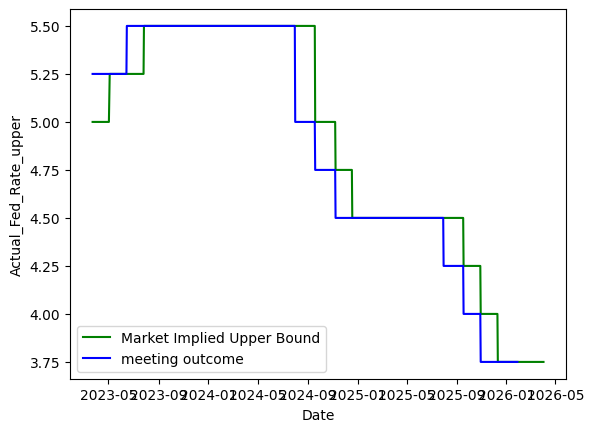

In [175]:
sns.lineplot(data=merged_data, x='Date', y='Actual_Fed_Rate_upper', label='Market Implied Upper Bound', color='green')
sns.lineplot(data=merged_data, x='Date', y='Meeting_Outcome_Rate', label='meeting outcome', color='blue')


In [208]:
# Root Mean Square Error (RMSE) decay

def plot_stratified_error_decay(df):


    df['Resolution_Date'] = pd.to_datetime(df['Meeting_Date'])
    
    # strictly positive "Days to Meeting"
    df['Days_to_Meeting'] = (df['Resolution_Date'] - df['Date']).dt.days
    
    # Filter out post-resolution lingering data
    calc_df = df[df['Days_to_Meeting'] >= 0].copy() 
    
    # get the discrete time buckets (Countdown)
    bins = [-1, 3, 7, 14, 30, 60]
    labels = ['0-3 Days', '4-7 Days', '8-14 Days', '15-30 Days', '31-60 Days']
    calc_df['Time_Bucket'] = pd.cut(calc_df['Days_to_Meeting'], bins=bins, labels=labels)
    
    #  Calculate Squared Errors for each row 
    calc_df['Poly_SE'] = ((calc_df['smoothed_mu_gaussian'] - calc_df['Meeting_Outcome_Rate']) * 100)**2
    calc_df['CME_SE'] = ((calc_df['Implied_Upper_Bound'] - calc_df['Meeting_Outcome_Rate']) * 100)**2
    

    # Dropna ensures we only plot buckets that actually have data
    rmse_df = calc_df.groupby('Time_Bucket', observed=True).agg(
        Poly_RMSE=('Poly_SE', lambda x: np.sqrt(x.mean())),
        CME_RMSE=('CME_SE', lambda x: np.sqrt(x.mean()))
    ).reset_index()
    
    plt.figure(figsize=(10, 6))
    
    plt.plot(rmse_df['Time_Bucket'], rmse_df['Poly_RMSE'], marker='o', markersize=8, linewidth=2.5, label='Polymarket Shadow Rate', color='#1f77b4')
    plt.plot(rmse_df['Time_Bucket'], rmse_df['CME_RMSE'], marker='s', markersize=8, linewidth=2.5, label='CME Futures (100 - P)', color='#d62728')
    
    plt.title('Prediction Error Decay: Polymarket vs. TradFi CME', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Countdown to FOMC Meeting', fontsize=12, fontweight='bold', labelpad=10)
    plt.ylabel('Root Mean Square Error (Basis Points)', fontsize=12, fontweight='bold', labelpad=10)
    
    plt.gca().invert_xaxis() 
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(fontsize=12, loc='upper left', frameon=True, shadow=True)
    plt.tight_layout()
    
    plt.show()
    
    return np.round(rmse_df, 2)


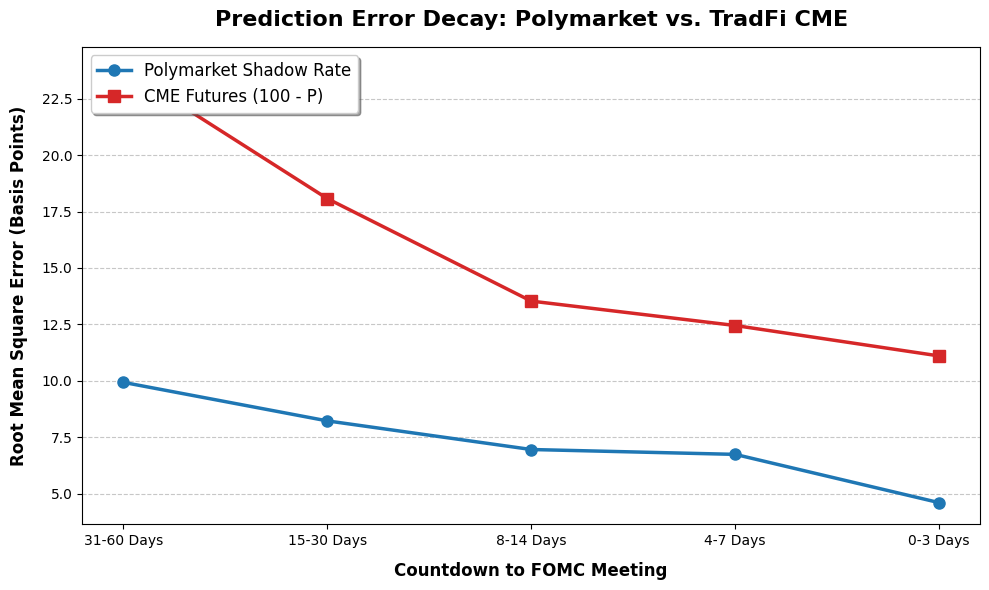

,Time_Bucket,Poly_RMSE,CME_RMSE
0,0-3 Days,4.61,11.11
1,4-7 Days,6.75,12.45
2,8-14 Days,6.96,13.54
3,15-30 Days,8.23,18.08
4,31-60 Days,9.94,23.83


In [209]:
plot_stratified_error_decay(merged_data)

In [100]:
merged_data.index = merged_data['Date']
merged_data.drop(columns=['Date'], inplace=True)


In [101]:
diff_data = merged_data.diff().dropna()

In [206]:

    #Tests the calibration of Polymarket implied distributions at a specific forecasting horizon.

def test_polymarket_calibration(df, target_days_ahead):
    print(f"Forecasts {target_days_ahead} Days Before Meeting")
    
    # 1. Filter for the specific forecast horizon
    # (We use a small window like +/- 1 day in case a specific day fell on a weekend)
    horizon_df = df[(df['Days_to_Meeting'] >= target_days_ahead - 1) & 
                    (df['Days_to_Meeting'] <= target_days_ahead + 1)].copy()
    
    # ensure statistical independence
    horizon_df = horizon_df.drop_duplicates(subset=['Meeting_Date'])
    
    if len(horizon_df) < 5:
        print(f" not enough independent meetings found for {target_days_ahead} days ahead")
        return None

    print(f"Testing {len(horizon_df)} independent FOMC meetings\n")
    horizon_df.dropna(inplace=True)
    mu = horizon_df['smoothed_mu_student_t'].values
    sigma = horizon_df['smoothed_sigma_student_t'].values
    nu = horizon_df['smoothed_nu'].values
    actual_outcome = horizon_df['Meeting_Outcome_Rate'].values
    
    # 3. Calculate the Probability Integral Transform (PIT)
    # This evaluates the Student-t CDF at the actual realized rate
    pit_values = student_t.cdf(actual_outcome, df=nu, loc=mu, scale=sigma)
    
    # 4. Formal Statistical Tests for Uniformity
    # Test K (Kolmogorov-Smirnov)
    ks_stat, ks_pvalue = stats.kstest(pit_values, 'uniform')
    
    # Test C (Cramér-von Mises)
    cvm_result = stats.cramervonmises(pit_values, 'uniform')
    cvm_stat = cvm_result.statistic
    cvm_pvalue = cvm_result.pvalue
    
    print(f"K-Statistic (Kolmogorov-Smirnov): {ks_stat:.4f} and p-value: {ks_pvalue:.4f}")
    print(f"C-Statistic (Cramér-von Mises)  : {cvm_stat:.4f} and p-value: {cvm_pvalue:.4f}")
    
    alpha = 0.05
    if ks_pvalue < alpha or cvm_pvalue < alpha:
        print("Conclusion: Reject the null hypothesis. Polymarket density is distorted by risk premia or miscalibration at this horizon.")
    else:
        print("Conclusion: Fail to reject the null.  Polymarket density is well-calibrated and serves as a valid physical density.")

    plt.figure(figsize=(8, 5))
    
    plt.hist(pit_values, bins=8, density=True, alpha=0.7, color="green", edgecolor='black')
    
    plt.axhline(1, color='red', linestyle='--', linewidth=2.5, label='Theoretical Uniform $U(0,1)$')
    
    plt.title(f'Probability Integral Transform (PIT) Histogram\n(Polymarket Forecasts {target_days_ahead} Days Ahead)', fontsize=14, fontweight='bold')
    plt.xlabel('PIT Value (Student-t CDF Evaluated at Realized Rate)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    
    plt.xlim(0, 1) 
    
    plt.legend(frameon=True, shadow=True)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    return pit_values



Forecasts 28 Days Before Meeting
Testing 24 independent FOMC meetings

K-Statistic (Kolmogorov-Smirnov): 0.2406 and p-value: 0.1176
C-Statistic (Cramér-von Mises)  : 0.2062 and p-value: 0.2566
Conclusion: Fail to reject the null.  Polymarket density is well-calibrated and serves as a valid physical density.


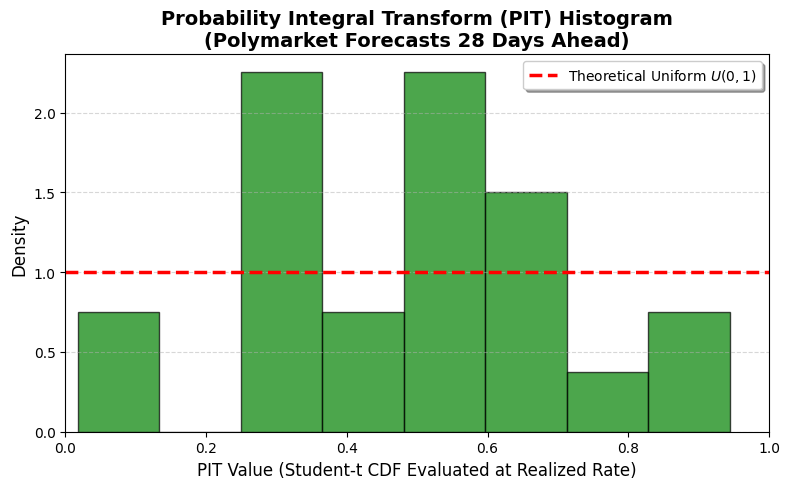

Forecasts 3 Days Before Meeting
Testing 24 independent FOMC meetings

K-Statistic (Kolmogorov-Smirnov): 0.2882 and p-value: 0.0348
C-Statistic (Cramér-von Mises)  : 0.4970 and p-value: 0.0396
Conclusion: Reject the null hypothesis. Polymarket density is distorted by risk premia or miscalibration at this horizon.


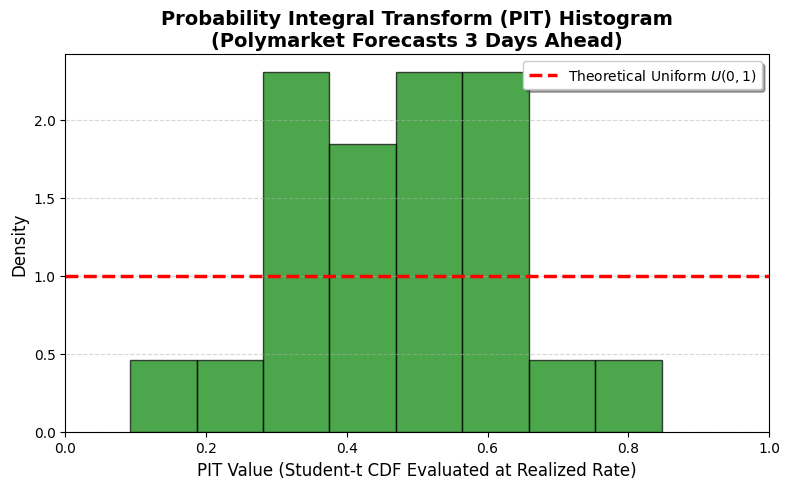

In [207]:

pit_28_days = test_polymarket_calibration(merged_data, target_days_ahead=28)
pit_3_days = test_polymarket_calibration(merged_data, target_days_ahead=3)